In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
dataset = EPFLP300()
subject, session, run = 1, "session_1", "run_1"
#dataset = BNCI2014008()
#subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
137 matching events found
No baseline correction applied


Number of events,137
Events,NonTarget: 114Target: 23
Time range,0.000 – 0.781 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


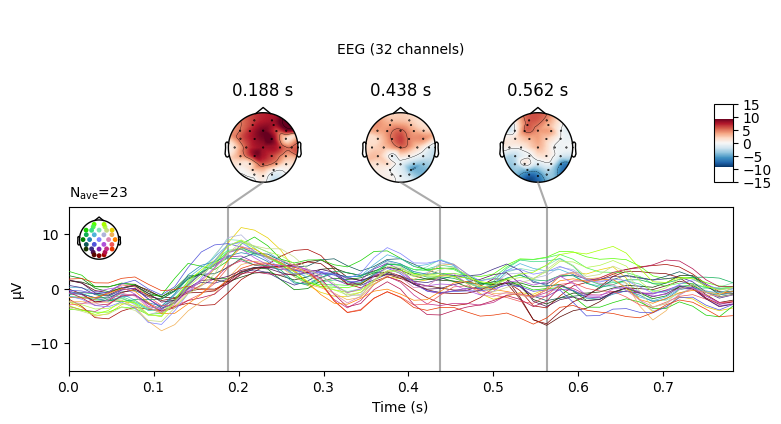

No projector specified for this dataset. Please consider the method self.add_proj.


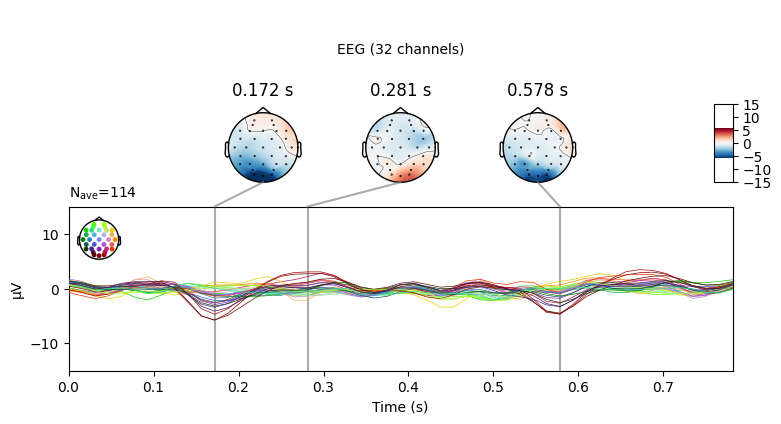

No projector specified for this dataset. Please consider the method self.add_proj.


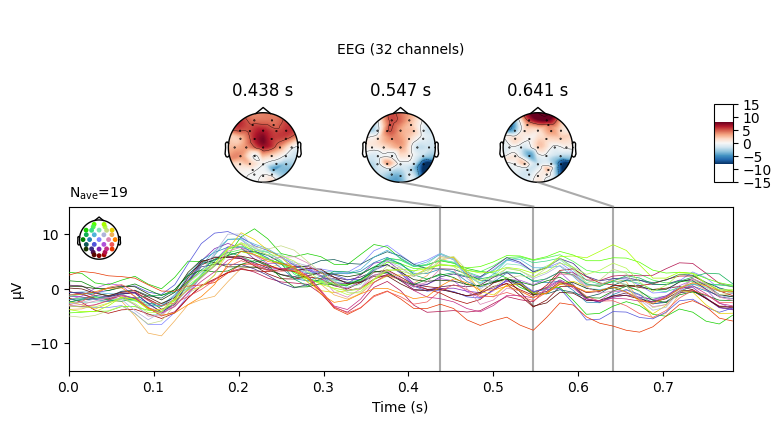

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]
"""
print(X_train.shape)
X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,), rank=8)
factors = [factors[0],tl.eye(X_train.shape[2])]
print(X_train.shape)
X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,), transpose=True)


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,2)), label='space')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1)), label='time')
#plt.legend()
"""
factors = [tl.eye(X_train.shape[1]),tl.eye(X_train.shape[2])]


In [8]:
import cupy

#fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
#for i in range(X_train.shape[1]):
#    w = cupy.asnumpy(factors[0][:,i])
#    plot_topomap(w, epochs.info, axes=axs[i], show=False)


In [9]:
tl.SVD_FUNS

{'numpy_svd': <bound method Backend.partial_svd of TensorLy cupy-backend>,
 'truncated_svd': <bound method Backend.truncated_svd of TensorLy cupy-backend>,
 'symeig_svd': <bound method Backend.symeig_svd of TensorLy cupy-backend>,
 'randomized_svd': <bound method Backend.randomized_svd of TensorLy cupy-backend>}

In [35]:
hoda = HODA(max_iter=128, rank=(5,5), tol=1e-6,
            initialize ='ones', verbose=True, var_thresh=0.9,
            shrinkage=('oas', 'oas'), toeplitz=(1,), solver='ratio-svd')
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)


[0/128]  shrinkage=0.1026  shrinkage=0.2296  step=1.4476e+01
[1/128]  shrinkage=0.0776  shrinkage=0.2348  step=3.3080e+00
[2/128]  shrinkage=0.0880  shrinkage=0.2297  step=3.0961e+00
[3/128]  shrinkage=0.0904  shrinkage=0.2802  step=2.3577e+00
[4/128]  shrinkage=0.0896  shrinkage=0.2779  step=2.5357e+00
[5/128]  shrinkage=0.0913  shrinkage=0.3059  step=1.8950e+00
[6/128]  shrinkage=0.0889  shrinkage=0.3162  step=1.2098e+00
[7/128]  shrinkage=0.0902  shrinkage=0.3177  step=9.6604e-01
[8/128]  shrinkage=0.0883  shrinkage=0.3374  step=1.8079e+00
[9/128]  shrinkage=0.0895  shrinkage=0.3261  step=2.4663e+00
[10/128]  shrinkage=0.0880  shrinkage=0.3504  step=2.4507e+00
[11/128]  shrinkage=0.0891  shrinkage=0.3341  step=2.0656e+00
[12/128]  shrinkage=0.0878  shrinkage=0.3576  step=2.0624e+00
[13/128]  shrinkage=0.0888  shrinkage=0.3417  step=2.0496e+00
[14/128]  shrinkage=0.0877  shrinkage=0.3612  step=1.2956e+00
[15/128]  shrinkage=0.0886  shrinkage=0.3482  step=1.2244e+00
[16/128]  shrinkag

HODA(max_iter=128, rank=(5, 5), shrinkage=('oas', 'oas'), solver='ratio-svd',
     toeplitz=(1,), tol=1e-06, var_thresh=0.9, verbose=True)

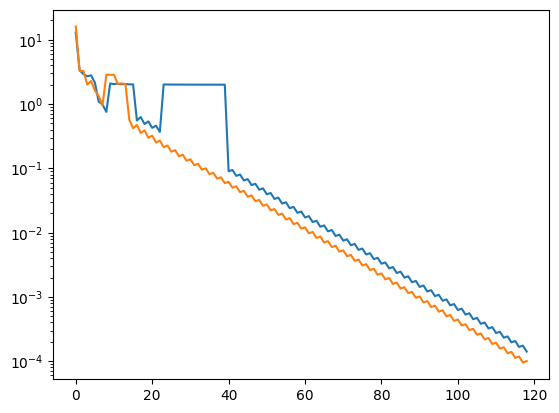

In [36]:
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

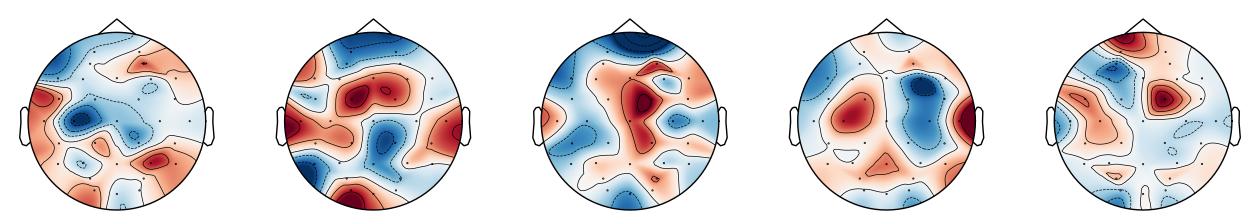

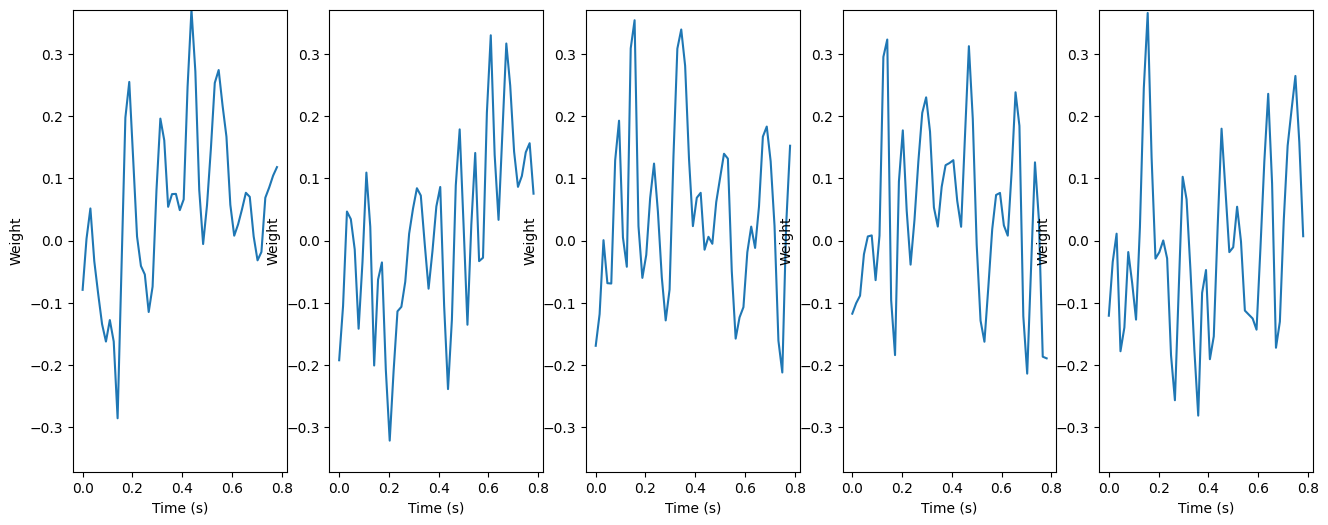

In [37]:
projs = [factors[k] @ p for k, p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(projs[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(projs[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(projs[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])


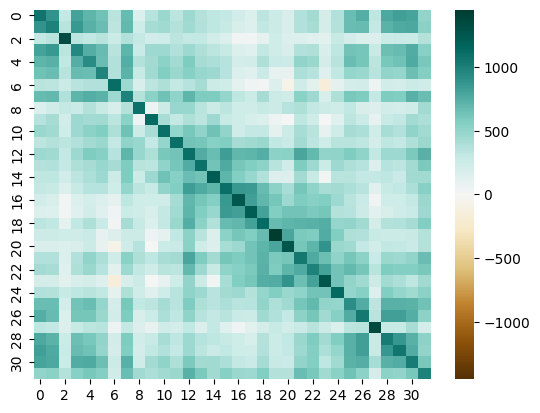

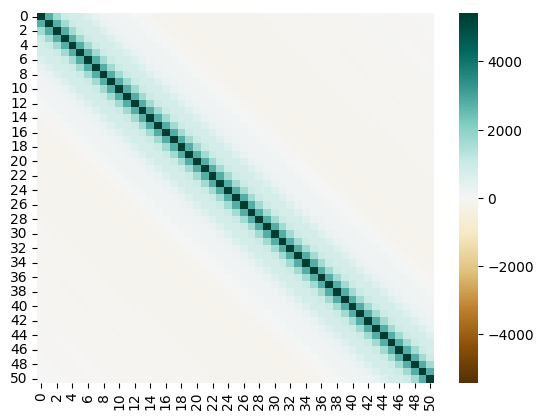

In [38]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

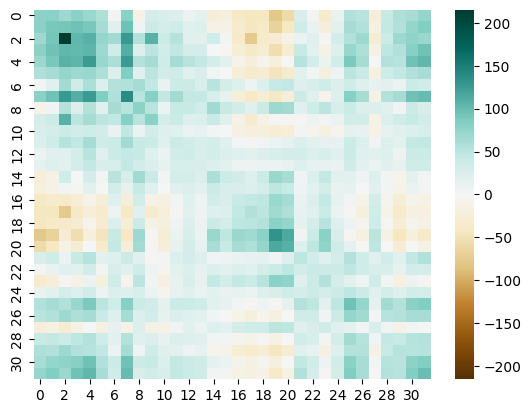

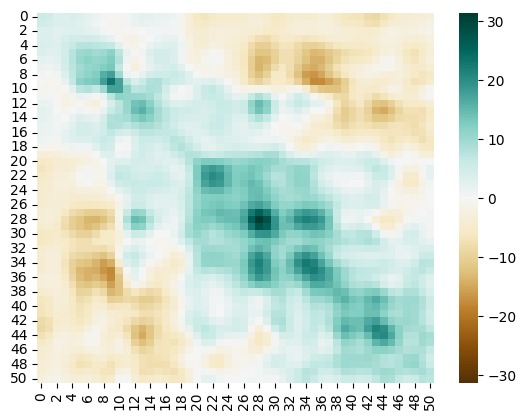

In [39]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

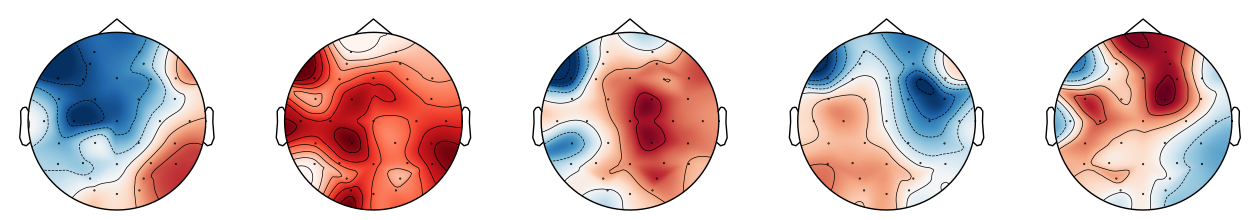

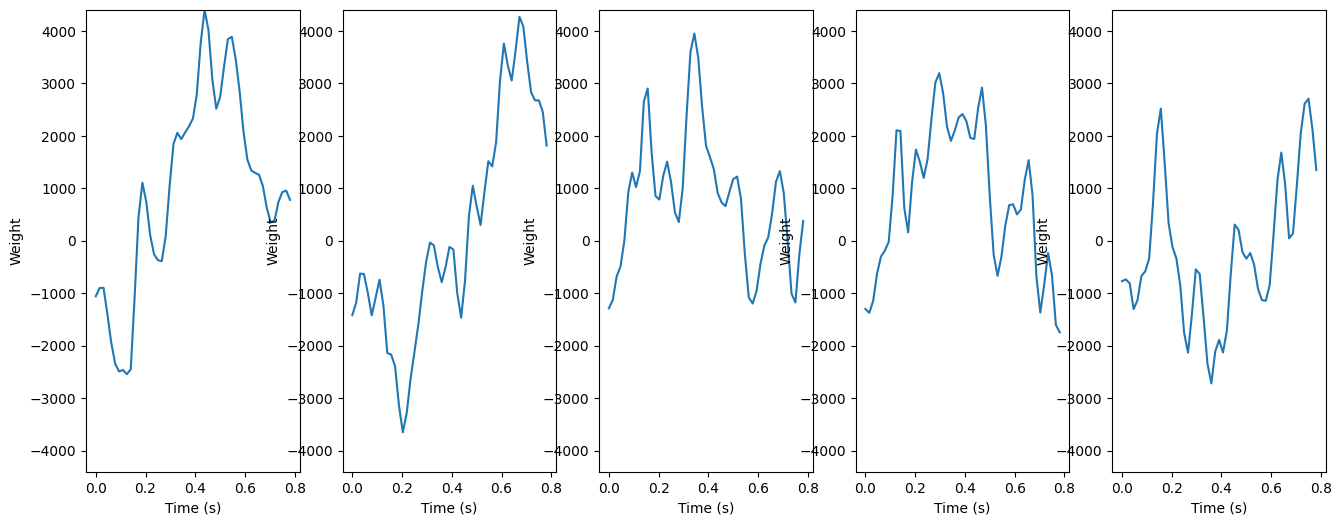

In [40]:
aps = [factors[k] @ hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(aps[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(aps[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(aps[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])

In [41]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')
#classifier = SVC(kernel='rbf', C=1, probability=True)

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
#feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
feature_order = np.arange(4)

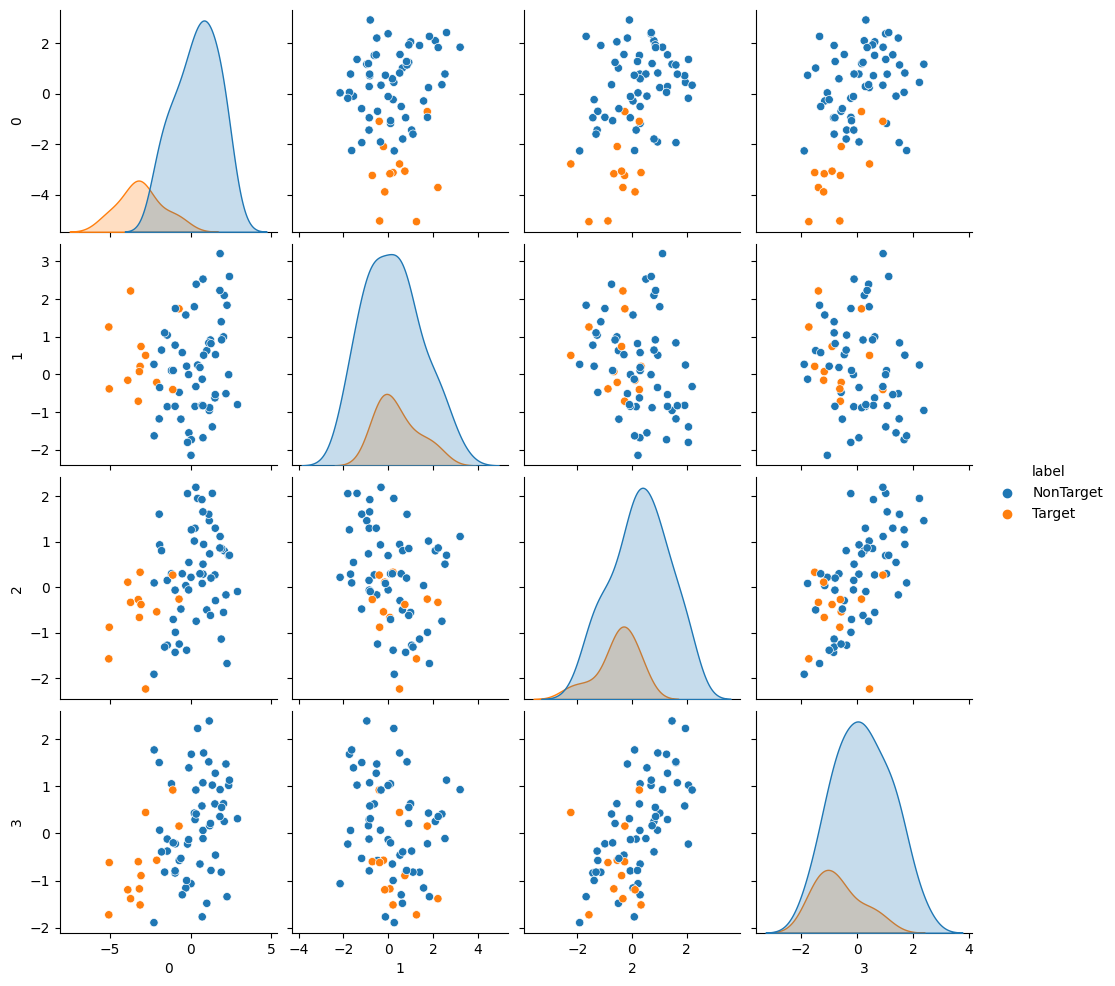

In [43]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [44]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

1.0

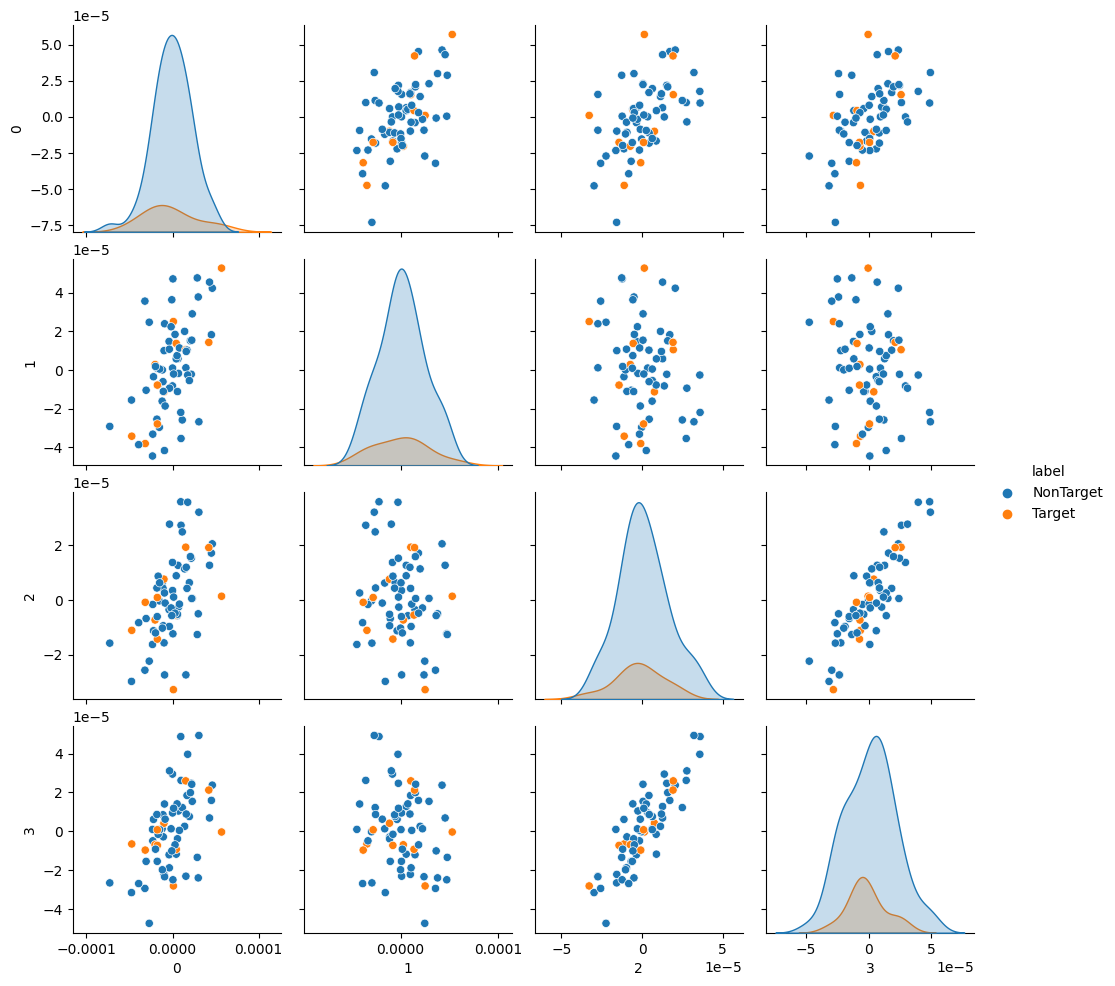

In [45]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [46]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.5015673981191222